# Demand & Inventory Intelligence System
## Retail Demand Forecasting and Inventory Risk Prediction
---
### Phase 3 — Data Cleaning & Data Quality Engineering

**Project:** Project FORESIGHT — Retail Demand & Inventory Intelligence  
**Author:** Data Science & Analytics Intern  
**Date:** August 2026  
**Prerequisite:** Phase 1 & 2 (Business Understanding & Data Profiling) — completed

---
### 1.1 Objective

This phase converts the two raw dataset families into **reliable, clean, validated datasets** that can be used safely for EDA, feature engineering, forecasting and inventory-risk analysis in later phases. The cleaning pipeline detects data-quality problems, handles missing values / duplicates / invalid values / cancellations / returns, validates dates, numbers, categories and relationships, preserves useful information, and produces a **data-quality report**.

### 1.2 Dataset families

1. **UCI Online Retail II** — 1,067,371 transaction line-items (2009-12-01 to 2011-12-09) from a UK-based online gift retailer.
2. **Synthetic multi-store relational dataset** (2022-01-01 to 2025-12-31): `store_master`, `sku_master`, `customer_master`, `calendar`, `sales_daily`, `inventory_snapshots`.

### 1.3 Cleaning principles (the rules we follow)

1. **Never modify raw data.** All outputs live under `data/processed/`.
2. **Never fabricate missing information.** Missing descriptions are recovered only from the same StockCode; otherwise a documented `Unknown Product` sentinel is used.
3. **Never silently delete records.** Every removal has a documented reason.
4. **Returns & cancellations are preserved separately**, not deleted.
5. **Missing Customer ID is not treated as invalid** — guest transactions are kept for sales analysis and only excluded from customer-level analysis.
6. **Legitimate retail outliers are kept**; outliers are *investigated*, not removed.
7. The pipeline is **reproducible** and driven by **reusable functions** in `src/data_cleaning.py`.

### 1.4 Deliverables of Phase 3

- Executed notebook: `notebooks/02_data_cleaning.ipynb`
- Reusable module: `src/data_cleaning.py`
- Clean datasets: `data/processed/*`
- Data-quality report: `docs/data_quality_report.json` + `.csv`
- Cleaning visualisations: `outputs/figures/*`


### 2. Load Raw Data

We locate the project root, import the reusable cleaning module (`src/data_cleaning.py`) and load every raw dataset. Parquet versions are used for the two large fact tables (`sales_daily`, `inventory_snapshots`).

In [1]:
# ---- Environment & project root -------------------------------------
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

warnings.filterwarnings('ignore')

# Locate project root robustly regardless of the kernel working directory.
def _find_project_root():
    d = os.getcwd()
    for _ in range(4):
        if os.path.exists(os.path.join(d, 'data', 'raw', 'online_retail_II.csv')):
            return d
        d = os.path.dirname(d)
    return os.path.abspath(os.path.join(os.getcwd(), '..'))

PROJECT_ROOT = _find_project_root()
sys.path.insert(0, PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))
print('Project root:', PROJECT_ROOT)

from data_cleaning import *
from data_cleaning import UNKNOWN_PRODUCT, TX_SALE, TX_RETURN, TX_CANCELLATION, TX_INVALID

dirs = ensure_directories()
print('Directories ready:', dirs)

print(f"pandas {pd.__version__} | numpy {np.__version__} | matplotlib {plt.matplotlib.__version__} | seaborn {sns.__version__}")

# ---- Consistent, colour-safe plotting style ---------------------------
# Validated default palette (dataviz reference palette):
# categorical slots in fixed order, light surface, recessive grids.
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
GOOD, WARN, SERIOUS, CRITICAL = '#0ca30c', '#fab219', '#ec835a', '#d03b3b'
INK, MUTED, GRID, SURFACE = '#0b0b0b', '#898781', '#e1e0d9', '#fcfcfb'
sns.set_theme(style='whitegrid', rc={
    'axes.facecolor': SURFACE, 'figure.facecolor': SURFACE,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelcolor': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'text.color': INK, 'axes.titleweight': 'bold', 'font.size': 11,
})
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'


Project root: C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence
Directories ready: {'raw_dir': 'C:\\Users\\SURAG\\Documents\\zidio\\Project_FORESIGHT\\Demand-Inventory-Intelligence\\data\\raw', 'processed_dir': 'C:\\Users\\SURAG\\Documents\\zidio\\Project_FORESIGHT\\Demand-Inventory-Intelligence\\data\\processed', 'docs_dir': 'C:\\Users\\SURAG\\Documents\\zidio\\Project_FORESIGHT\\Demand-Inventory-Intelligence\\docs', 'figures_dir': 'C:\\Users\\SURAG\\Documents\\zidio\\Project_FORESIGHT\\Demand-Inventory-Intelligence\\outputs\\figures'}
pandas 3.0.5 | numpy 2.5.2 | matplotlib 3.11.1 | seaborn 0.13.2


In [2]:
# ---- Load raw data ---------------------------------------------------
raw_uci = load_online_retail_data()
syn = load_synthetic_retail_data()

summary = pd.DataFrame([
    {'Dataset': 'online_retail_II', 'Rows': len(raw_uci), 'Columns': raw_uci.shape[1], 'Source': 'CSV (95 MB)'},
    {'Dataset': 'store_master', 'Rows': len(syn['store_master']), 'Columns': syn['store_master'].shape[1], 'Source': 'CSV'},
    {'Dataset': 'sku_master', 'Rows': len(syn['sku_master']), 'Columns': syn['sku_master'].shape[1], 'Source': 'CSV'},
    {'Dataset': 'customer_master', 'Rows': len(syn['customer_master']), 'Columns': syn['customer_master'].shape[1], 'Source': 'CSV'},
    {'Dataset': 'calendar', 'Rows': len(syn['calendar']), 'Columns': syn['calendar'].shape[1], 'Source': 'CSV'},
    {'Dataset': 'sales_daily', 'Rows': len(syn['sales_daily']), 'Columns': syn['sales_daily'].shape[1], 'Source': 'Parquet (6 MB)'},
    {'Dataset': 'inventory_snapshots', 'Rows': len(syn['inventory_snapshots']), 'Columns': syn['inventory_snapshots'].shape[1], 'Source': 'Parquet (5 MB)'},
])
display(summary)

# Working containers shared by all sections.
clean = {}
reports = {}
print('\nAll raw datasets loaded.')


,Dataset,Rows,Columns,Source
0,online_retail_II,1067371,8,CSV (95 MB)
1,store_master,30,8,CSV
2,sku_master,5000,12,CSV
3,customer_master,10000,5,CSV
4,calendar,1461,12,CSV
5,sales_daily,1461000,9,Parquet (6 MB)
6,inventory_snapshots,1461000,9,Parquet (5 MB)



All raw datasets loaded.


### 3. Data Quality Assessment (Baseline)

Before cleaning we profile every dataset: schema, data types, missing values, exact duplicates, and date ranges. This is the *baseline* that the cleaning decisions in the following sections are measured against. For the Online Retail II dataset we also run the authoritative cleaning pipeline (`clean_online_retail`) so that every later section reports the same numbers.

In [3]:
# ---- Baseline profile of all raw datasets ---------------------------
def _baseline(name, df):
    return {
        'Dataset': name,
        'Rows': len(df),
        'Columns': df.shape[1],
        'Null Cells': int(df.isna().sum().sum()),
        'Exact Duplicate Rows': int(df.duplicated().sum()),
    }

baseline = pd.DataFrame([
    _baseline('online_retail_II', raw_uci),
    _baseline('store_master', syn['store_master']),
    _baseline('sku_master', syn['sku_master']),
    _baseline('customer_master', syn['customer_master']),
    _baseline('calendar', syn['calendar']),
    _baseline('sales_daily', syn['sales_daily']),
    _baseline('inventory_snapshots', syn['inventory_snapshots']),
])
display(baseline)


,Dataset,Rows,Columns,Null Cells,Exact Duplicate Rows
0,online_retail_II,1067371,8,247389,34335
1,store_master,30,8,0,0
2,sku_master,5000,12,0,0
3,customer_master,10000,5,0,0
4,calendar,1461,12,0,0
5,sales_daily,1461000,9,0,0
6,inventory_snapshots,1461000,9,0,0


In [4]:
# ---- UCI: schema validation + missing/duplicate detail ---------------
schema_uci = validate_schema(raw_uci, ONLINE_RETAIL_REQUIRED_COLUMNS, 'online_retail_ii')
print('UCI schema OK:', schema_uci['schema_ok'])
if not schema_uci['schema_ok']:
    print('Missing columns:', schema_uci['missing_columns'])

uci_missing = missing_value_summary(raw_uci, 'online_retail_ii')
display(pd.DataFrame({
    'Column': list(uci_missing['missing_by_column'].keys()),
    'Missing': [v['count'] for v in uci_missing['missing_by_column'].values()],
    'Missing %': [v['pct'] for v in uci_missing['missing_by_column'].values()],
}))

print(f"Exact duplicate rows in raw UCI data: {raw_uci.duplicated().sum():,} "
      f"({raw_uci.duplicated().sum()/len(raw_uci)*100:.2f}%)")
print(f"Missing Customer ID: {raw_uci['Customer ID'].isna().sum():,} "
      f"({raw_uci['Customer ID'].isna().mean()*100:.2f}%)")
print(f"Missing Description: {raw_uci['Description'].isna().sum():,} "
      f"({raw_uci['Description'].isna().mean()*100:.2f}%)")


UCI schema OK: True


,Column,Missing,Missing %
0,Description,4382,0.4105
1,Customer ID,243007,22.7669


Exact duplicate rows in raw UCI data: 34,335 (3.22%)
Missing Customer ID: 243,007 (22.77%)
Missing Description: 4,382 (0.41%)


In [5]:
# ---- UCI: run the authoritative cleaning to establish the baseline ---
uci_clean, uci_report = clean_online_retail(raw_uci)
clean['online_retail'] = uci_clean
reports['online_retail_ii'] = uci_report

print(f"Raw rows        : {uci_report['original_rows']:,}")
print(f"Clean rows      : {uci_report['final_rows']:,}")
print(f"Rows removed    : {uci_report['original_rows'] - uci_report['final_rows']:,} (exact duplicates)")
print(f"Cancellations   : {uci_report['cancellation_count']:,} ({uci_report['cancellation_pct']:.2f}%)")
print(f"Returns         : {uci_report['return_count']:,}")
print(f"Invalid lines   : {uci_report['invalid_count']:,}")
print(f"Guest txns      : {uci_report['guest_transaction_count']:,} ({uci_report['guest_transaction_pct']:.2f}%)")


Raw rows        : 1,067,371
Clean rows      : 1,033,036
Rows removed    : 34,335 (exact duplicates)
Cancellations   : 19,104 (1.79%)
Returns         : 3,393
Invalid lines   : 6
Guest txns      : 235,151 (22.76%)


### 4. Duplicate Handling

**Decision rule.** Exact full-row duplicates are treated as data-entry errors (a line recorded twice) and are removed from the *processed* dataset. The raw files are never touched. We first verify that the duplicates are indeed exact (all columns identical) and quantify them per transaction class before removal. For the relational tables the relevant uniqueness constraint is the business key: `store_id`, `sku_id`, `customer_id`, `calendar.date`, and the `(date, store_id, sku_id)` grain of the fact tables.

In [6]:
# ---- UCI: exact-duplicate analysis ----------------------------------
dups_uci = raw_uci.duplicated(keep=False)   # mark all occurrences of duplicated rows
dup_rows = raw_uci[dups_uci]
print(f"Rows participating in a duplicate set : {len(dup_rows):,} "
      f"({len(dup_rows)/len(raw_uci)*100:.2f}%)")
print(f"Duplicates removed (kept first)       : {uci_report['duplicate_rows']:,} "
      f"({uci_report['duplicate_pct']:.2f}%)")

# Confirm duplicates are exact across every column
exact = dup_rows.groupby(list(raw_uci.columns)).size()
print(f"Unique duplicated row signatures       : {len(exact)}")
print("Sample duplicated signature:")
display(dup_rows.head(6))


Rows participating in a duplicate set : 67,242 (6.30%)
Duplicates removed (kept first)       : 34,335 (3.22%)
Unique duplicated row signatures       : 25061
Sample duplicated signature:


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom


In [7]:
# ---- Synthetic masters: ID uniqueness ---------------------------------
store_master, store_rep = clean_store_master(syn['store_master'])
clean['store_master'] = store_master
reports['store_master'] = store_rep

sku_master, sku_rep = clean_sku_master(syn['sku_master'])
clean['sku_master'] = sku_master
reports['sku_master'] = sku_rep

customer_master, cust_rep = clean_customer_master(syn['customer_master'])
clean['customer_master'] = customer_master
reports['customer_master'] = cust_rep

id_checks = pd.DataFrame([
    {'Table': 'store_master', 'Rows': len(store_master), 'Duplicate IDs': store_rep['duplicate_store_ids'], 'Missing IDs': store_rep['missing_ids']},
    {'Table': 'sku_master', 'Rows': len(sku_master), 'Duplicate IDs': sku_rep['duplicate_sku_ids'], 'Missing IDs': sku_rep['missing_ids']},
    {'Table': 'customer_master', 'Rows': len(customer_master), 'Duplicate IDs': cust_rep['duplicate_customer_ids'], 'Missing IDs': cust_rep['missing_ids']},
])
display(id_checks)
print('Store master status:', store_rep['quality_status'], '| SKU master status:', sku_rep['quality_status'],
      '| Customer master status:', cust_rep['quality_status'])


,Table,Rows,Duplicate IDs,Missing IDs
0,store_master,30,0,0
1,sku_master,5000,0,0
2,customer_master,10000,0,0


Store master status: PASS | SKU master status: PASS | Customer master status: PASS


### 5. Missing Value Handling

Two genuine missing-value problems exist in the UCI data:

1. **Description (4,382 rows / 0.41%).** Missing descriptions are recovered from other line-items sharing the same `StockCode` (modal description). Lines whose StockCode never carries a known description anywhere are labelled `Unknown Product` — we never invent product names.
2. **Customer ID (243,007 rows / 22.77%).** This is **not** invalid — these are guest checkout transactions. They are **kept** for sales/demand analysis and flagged with `is_guest_transaction=True` so that customer *segmentation* analyses can exclude them without losing sales volume.

The synthetic relational tables contain no missing values.

In [8]:
# ---- UCI: Description recovery ---------------------------------------
print('Recovered from same StockCode :', int((uci_clean['description_source']=='recovered').sum()))
print('Unknown Product (unrecoverable):', int((uci_clean['description_source']=='unknown').sum()))
print('Originally present            :', int((uci_clean['description_source']=='original').sum()))

# Example of a recovered description
rec = uci_clean[uci_clean['description_source']=='recovered'].head(3)
display(rec[['Invoice', 'StockCode', 'Description', 'description_source']])

print('Remaining missing Description after cleaning: ', int(uci_clean['Description'].isna().sum()))


Recovered from same StockCode : 3912
Unknown Product (unrecoverable): 363
Originally present            : 1028761


,Invoice,StockCode,Description,description_source
3114,489655,20683,RAIN GIRL CHILDS UMBRELLA,recovered
3161,489659,21350,GINGHAM HEART WREATH,recovered
3731,489781,84292,ROSE PINK METAL FOLDING CHAIR,recovered


Remaining missing Description after cleaning:  0


In [9]:
# ---- UCI: Guest-customer treatment -----------------------------------
guest = uci_clean[uci_clean['is_guest_transaction']]
ident = uci_clean[~uci_clean['is_guest_transaction']]
print(f"Guest transactions (kept for sales analysis): {len(guest):,} ({len(guest)/len(uci_clean)*100:.2f}%)")
print(f"Identified-customer transactions              : {len(ident):,} ({len(ident)/len(uci_clean)*100:.2f}%)")
print('\n-> Use full dataset for demand/sales analysis; use only identified customers for segmentation.')


Guest transactions (kept for sales analysis): 235,151 (22.76%)
Identified-customer transactions              : 797,885 (77.24%)

-> Use full dataset for demand/sales analysis; use only identified customers for segmentation.


In [10]:
# ---- Synthetic: missing-value scan -----------------------------------
for key in ['store_master', 'sku_master', 'customer_master', 'calendar', 'sales_daily', 'inventory_snapshots']:
    df = syn[key]
    total = int(df.isna().sum().sum())
    if total:
        cols = [c for c, n in df.isna().sum().items() if n > 0]
        print(f"{key:24s} missing cells = {total:,}  (columns: {cols})")
    else:
        print(f"{key:24s} missing cells = 0")


store_master             missing cells = 0
sku_master               missing cells = 0
customer_master          missing cells = 0
calendar                 missing cells = 0
sales_daily              missing cells = 0
inventory_snapshots      missing cells = 0


### 6. Invalid Value Handling

For the UCI data we analyse `Quantity` and `Price` in detail. Retail transaction logs legitimately contain negative quantities (cancellations and returns), zero prices (postage, samples, manual adjustments) and negative prices (accounting journal lines). Instead of deleting them we classify every line with a documented `transaction_type`, and annotate `price_category` + `is_special_transaction` so downstream analysis can include or exclude them deliberately.

In [11]:
# ---- UCI: Quantity profile (raw) -------------------------------------
qty = raw_uci['Quantity']
qty_prof = pd.DataFrame([
    {'Band': 'Quantity < 0', 'Rows': int((qty<0).sum()), 'Share %': round((qty<0).mean()*100, 3)},
    {'Band': 'Quantity == 0', 'Rows': int((qty==0).sum()), 'Share %': round((qty==0).mean()*100, 3)},
    {'Band': 'Quantity > 0', 'Rows': int((qty>0).sum()), 'Share %': round((qty>0).mean()*100, 3)},
])
display(qty_prof)
print('Quantity min / max:', qty.min(), '/', qty.max())


,Band,Rows,Share %
0,Quantity < 0,22950,2.15
1,Quantity == 0,0,0.00
2,Quantity > 0,1044421,97.85


Quantity min / max: -80995 / 80995


In [12]:
# ---- UCI: Price profile (raw) ----------------------------------------
price = raw_uci['Price']
price_prof = pd.DataFrame([
    {'Band': 'Price < 0', 'Rows': int((price<0).sum()), 'Share %': round((price<0).mean()*100, 4)},
    {'Band': 'Price == 0', 'Rows': int((price==0).sum()), 'Share %': round((price==0).mean()*100, 3)},
    {'Band': 'Price > 0', 'Rows': int((price>0).sum()), 'Share %': round((price>0).mean()*100, 3)},
])
display(price_prof)
print('Price min / max:', price.min(), '/', price.max())

# Investigate zero / negative price lines before any decision.
special = raw_uci[price <= 0]
print('\nDescription of zero/negative-price lines (top 12):')
print(special['Description'].value_counts().head(12).to_string())
print('\nAll negative-price lines are accounting journal lines:')
print(special[special['Price']<0][['Invoice','StockCode','Description','Quantity','Price']].to_string())


,Band,Rows,Share %
0,Price < 0,5,0.0005
1,Price == 0,6202,0.5810
2,Price > 0,1061164,99.4180


Price min / max: -53594.36 / 38970.0

Description of zero/negative-price lines (top 12):
Description
check                           162
?                                92
damages                          84
damaged                          81
found                            28
missing                          27
sold as set on dotcom            20
Damaged                          17
adjustment                       16
OWL DOORSTOP                     15
POLYESTER FILLER PAD 45x45cm     12
dotcom                           12

All negative-price lines are accounting journal lines:
        Invoice StockCode      Description  Quantity     Price
179403  A506401         B  Adjust bad debt         1 -53594.36
276274  A516228         B  Adjust bad debt         1 -44031.79
403472  A528059         B  Adjust bad debt         1 -38925.87
825444  A563186         B  Adjust bad debt         1 -11062.06
825445  A563187         B  Adjust bad debt         1 -11062.06


In [13]:
# ---- UCI: transaction-type & price-category annotation ---------------
print('transaction_type distribution (clean):')
display(pd.DataFrame.from_dict(
    uci_report['transaction_type_counts'], orient='index', columns=['Rows']).rename_axis('transaction_type'))

print('price_category distribution (clean):')
display(uci_clean['price_category'].value_counts().rename('Rows').to_frame())

print(f"Special transactions (price <= 0) kept but flagged: {uci_clean['is_special_transaction'].sum():,}")
print(f"Invalid (accounting adjustment) lines removed from sales: {uci_report['invalid_values']}")


transaction_type distribution (clean):


,Rows
transaction_type,
SALE,1010533
CANCELLATION,19104
RETURN,3393
INVALID,6


price_category distribution (clean):


,Rows
price_category,
PRICE_POSITIVE,1027017
PRICE_ZERO,6014
PRICE_NEGATIVE,5


Special transactions (price <= 0) kept but flagged: 6,019
Invalid (accounting adjustment) lines removed from sales: 6


In [14]:
# ---- Synthetic: invalid-value & flag checks --------------------------
flag_checks = pd.DataFrame([
    {'Table': 'customer_master', 'Check': 'loyalty_member in {0,1}', 'Invalid': cust_rep['invalid_loyalty_member']},
    {'Table': 'customer_master', 'Check': 'valid customer_segment', 'Invalid': cust_rep['invalid_segment']},
    {'Table': 'store_master', 'Check': 'store_size_sqft > 0', 'Invalid': store_rep['invalid_store_sizes']},
    {'Table': 'sku_master', 'Check': 'cost_price > 0', 'Invalid': sku_rep['invalid_cost_price']},
    {'Table': 'sku_master', 'Check': 'base_price > 0', 'Invalid': sku_rep['invalid_base_price']},
    {'Table': 'sku_master', 'Check': 'lead_time_days > 0', 'Invalid': sku_rep['invalid_lead_time_days']},
    {'Table': 'sku_master', 'Check': 'reorder_point >= 0', 'Invalid': sku_rep['negative_reorder_point']},
    {'Table': 'sku_master', 'Check': 'safety_stock >= 0', 'Invalid': sku_rep['negative_safety_stock']},
])
display(flag_checks)


,Table,Check,Invalid
0,customer_master,"loyalty_member in {0,1}",0
1,customer_master,valid customer_segment,0
2,store_master,store_size_sqft > 0,0
3,sku_master,cost_price > 0,0
4,sku_master,base_price > 0,0
5,sku_master,lead_time_days > 0,0
6,sku_master,reorder_point >= 0,0
7,sku_master,safety_stock >= 0,0


### 7. Transaction Cleaning

Every UCI line is classified with the following **documented rule set** (discovered by inspecting the actual data):

| Rule | Condition | transaction_type | Treatment |
|---|---|---|---|
| 1 | `Invoice` starts with `C` | CANCELLATION | kept in a separate dataset |
| 2 | `Invoice` starts with `A` (all are `Adjust bad debt` journal lines) | INVALID | excluded from sales |
| 3 | `Price < 0` (accounting adjustment) | INVALID | excluded from sales |
| 4 | `Quantity < 0` (non-C, non-A) | RETURN | kept in a separate dataset |
| 5 | otherwise | SALE | valid sales transaction |

Zero-price `SALE` lines (postage, samples, manual adjustments) are **kept** and flagged via `price_category` / `is_special_transaction`; they are not silently removed.

In [15]:
# ---- UCI: final cleaned transaction frame ----------------------------
print('Cleaned Online Retail II schema:')
print(list(uci_clean.columns))
print('\nSample of cleaned sales lines:')
display(uci_clean[uci_clean['transaction_type']==TX_SALE][
    ['Invoice','StockCode','Description','Quantity','Price','InvoiceDate','Country',
     'transaction_type','price_category','is_guest_transaction','description_source']
].head(8))


Cleaned Online Retail II schema:
['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'transaction_type', 'description_recovered', 'description_source', 'invoice_date_only', 'invoice_year', 'invoice_month', 'invoice_weekday', 'is_guest_transaction', 'price_category', 'is_special_transaction']

Sample of cleaned sales lines:


,Invoice,StockCode,Description,Quantity,Price,InvoiceDate,Country,transaction_type,price_category,is_guest_transaction,description_source
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,6.95,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
1,489434,79323P,PINK CHERRY LIGHTS,12,6.75,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
2,489434,79323W,WHITE CHERRY LIGHTS,12,6.75,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2.10,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,1.25,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,1.65,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
6,489434,21871,SAVE THE PLANET MUG,24,1.25,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,5.95,2009-12-01 07:45:00,United Kingdom,SALE,PRICE_POSITIVE,False,original


In [16]:
# ---- UCI: description source & date-field sanity ---------------------
print('description_source:')
print(uci_clean['description_source'].value_counts().to_string())
print('\nDate columns added during cleaning:')
print(uci_clean[['invoice_year','invoice_month','invoice_weekday']].head(3).to_string())
print('\nNo missing values remain in Description:', int(uci_clean['Description'].isna().sum()) == 0)


description_source:
description_source
original     1028761
recovered       3912
unknown          363

Date columns added during cleaning:
   invoice_year  invoice_month  invoice_weekday
0          2009             12                1
1          2009             12                1
2          2009             12                1

No missing values remain in Description: True


### 8. Return & Cancellation Handling

Cancellations and returns are **not deleted** — they are material business events (lost revenue, refund exposure, return logistics). They are split into dedicated analytical datasets so they can be modelled independently, and their monetary impact is quantified.

In [17]:
# ---- UCI: split into analytical components ---------------------------
uci_sales, uci_returns, uci_cancellations, uci_invalid = split_transactions(uci_clean)

split_table = pd.DataFrame([
    {'Component': 'Valid sales (SALE)', 'Rows': len(uci_sales), 'Share %': round(len(uci_sales)/len(uci_clean)*100, 2)},
    {'Component': 'Returns (RETURN)', 'Rows': len(uci_returns), 'Share %': round(len(uci_returns)/len(uci_clean)*100, 2)},
    {'Component': 'Cancellations (CANCELLATION)', 'Rows': len(uci_cancellations), 'Share %': round(len(uci_cancellations)/len(uci_clean)*100, 2)},
    {'Component': 'Invalid / adjustments (INVALID)', 'Rows': len(uci_invalid), 'Share %': round(len(uci_invalid)/len(uci_clean)*100, 2)},
])
display(split_table)
assert len(uci_sales)+len(uci_returns)+len(uci_cancellations)+len(uci_invalid) == len(uci_clean)
print('Split is exhaustive (components sum to the cleaned frame).')


,Component,Rows,Share %
0,Valid sales (SALE),1010533,97.82
1,Returns (RETURN),3393,0.33
2,Cancellations (CANCELLATION),19104,1.85
3,Invalid / adjustments (INVALID),6,0.00


Split is exhaustive (components sum to the cleaned frame).


In [18]:
# ---- UCI: monetary impact of returns & cancellations ------------------
def _value(df):
    return float((df['Quantity'] * df['Price']).sum())

print(f"Gross value of valid sales lines : {_value(uci_sales):+,.2f}")
print(f"Value of returns                 : {_value(uci_returns):+,.2f}")
print(f"Value of cancellations          : {_value(uci_cancellations):+,.2f}")
print(f"Value of invalid/adjustment lines: {_value(uci_invalid):+,.2f}")

# Cancellation vs return samples
print('\nSample cancellation lines:')
display(uci_cancellations[['Invoice','StockCode','Description','Quantity','Price']].head(5))
print('\nSample return lines:')
display(uci_returns[['Invoice','StockCode','Description','Quantity','Price']].head(5))


Gross value of valid sales lines : +20,465,198.39
Value of returns                 : +0.00
Value of cancellations          : -1,462,050.61
Value of invalid/adjustment lines: -147,614.08

Sample cancellation lines:


,Invoice,StockCode,Description,Quantity,Price
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2.95
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,1.65
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,4.25
181,C489449,21896,POTTING SHED TWINE,-6,2.10
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2.95



Sample return lines:


,Invoice,StockCode,Description,Quantity,Price
263,489464,21733,85123a mixed,-96,0.0
283,489463,71477,short,-240,0.0
284,489467,85123A,21733 mixed,-192,0.0
470,489521,21646,Unknown Product,-50,0.0
3114,489655,20683,RAIN GIRL CHILDS UMBRELLA,-44,0.0


In [19]:
# ---- Synthetic: returns/cancellations modelling note -----------------
print('The relational fact tables are DAILY AGGREGATES at (date, store_id, sku_id) grain.')
print('Returns and cancellations are not recorded as separate line items; they are netted')
print('into units_sold / total_revenue. Returns/cancellation analytics are therefore modelled')
print('only on the Online Retail II transaction log, while the relational tables model')
print('net demand and inventory movement.')


The relational fact tables are DAILY AGGREGATES at (date, store_id, sku_id) grain.
Returns and cancellations are not recorded as separate line items; they are netted
into units_sold / total_revenue. Returns/cancellation analytics are therefore modelled
only on the Online Retail II transaction log, while the relational tables model
net demand and inventory movement.


### 9. Date/Time Cleaning

All date columns are converted to `datetime64` and validated for missing, invalid and future values. The calendar dimension is additionally checked for **internal consistency** (its `year/month/day/quarter/week_of_year/day_of_week/is_weekend` attributes must match the actual date).

In [20]:
# ---- UCI: InvoiceDate validation -------------------------------------
dt = uci_clean['InvoiceDate']
print('Date range            :', dt.min(), '->', dt.max())
print('Total distinct days   :', dt.dt.normalize().nunique())
print('Invalid / missing     :', int(dt.isna().sum()))
print('Future dates (> 2011) :', int((dt > '2011-12-31').sum()))
print('Weekend transactions  :', int(dt.dt.dayofweek.isin([5,6]).sum()))


Date range            : 2009-12-01 07:45:00 -> 2011-12-09 12:50:00
Total distinct days   : 604
Invalid / missing     : 0
Future dates (> 2011) : 0
Weekend transactions  : 133419


In [21]:
# ---- Synthetic: calendar validation -----------------------------------
calendar_clean, cal_rep = clean_calendar(syn['calendar'])
clean['calendar'] = calendar_clean
reports['calendar'] = cal_rep

print('Calendar status     :', cal_rep['quality_status'])
print('Date range          :', cal_rep['date_validation']['min_date'], '->', cal_rep['date_validation']['max_date'])
print('Duplicate dates     :', cal_rep['duplicate_dates'])
print('Attribute mismatches:', cal_rep['attribute_mismatch_total'])
display(pd.DataFrame.from_dict(cal_rep['attribute_mismatches'], orient='index', columns=['Mismatch Rows']).rename_axis('attribute'))


Calendar status     : PASS
Date range          : 2022-01-01 00:00:00 -> 2025-12-31 00:00:00
Duplicate dates     : 0
Attribute mismatches: 0


,Mismatch Rows
attribute,
year,0
month,0
day,0
quarter,0
week_of_year,0
day_of_week,0
is_weekend,0
is_holiday,0


In [22]:
# ---- Synthetic: opening / signup date checks --------------------------
master_date_checks = pd.DataFrame([
    {'Table': 'store_master', 'Column': 'opening_date', 'Min': store_rep['date_validation']['min_date'],
     'Max': store_rep['date_validation']['max_date'], 'Invalid': store_rep['date_validation']['invalid_dates'],
     'Future': store_rep['date_validation']['future_dates']},
    {'Table': 'customer_master', 'Column': 'signup_date', 'Min': cust_rep['date_validation']['min_date'],
     'Max': cust_rep['date_validation']['max_date'], 'Invalid': cust_rep['date_validation']['invalid_dates'],
     'Future': cust_rep['date_validation']['future_dates']},
])
display(master_date_checks)


,Table,Column,Min,Max,Invalid,Future
0,store_master,opening_date,2015-08-03 00:00:00,2021-12-07 00:00:00,0,0
1,customer_master,signup_date,2019-01-01 00:00:00,2023-12-28 00:00:00,0,0


### 10. Numerical Validation

We validate every numeric field for negatives, zeros and plausible bounds, and validate the **grain** of the fact tables. For `sales_daily` we also check the internal identity `total_revenue == units_sold * avg_unit_price`; for `inventory_snapshots` we check the canonical balance equation (see the documented semantic below).

In [23]:
# ---- UCI: numeric profiles -------------------------------------------
uci_num = uci_report['numeric_validation']
num_rows = []
for col, prof in uci_num.items():
    num_rows.append({'Column': col, 'Non-null': prof['non_null'], 'Negative': prof['negative'],
                     'Zero': prof['zero'], 'Positive': prof['positive'],
                     'Min': prof['min'], 'Max': prof['max']})
display(pd.DataFrame(num_rows))


,Column,Non-null,Negative,Zero,Positive,Min,Max
0,Quantity,1067371,22950,0,1044421,-80995.00,80995.0
1,Price,1067371,5,6202,1061164,-53594.36,38970.0


In [24]:
# ---- Synthetic: sales_daily validation -------------------------------
sales_daily, sales_rep = clean_sales_daily(
    syn['sales_daily'],
    store_ids=store_master['store_id'],
    sku_ids=sku_master['sku_id'],
    calendar_dates=calendar_clean['date'].astype(str),
)
clean['sales_daily'] = sales_daily
reports['sales_daily'] = sales_rep

print('Sales status            :', sales_rep['quality_status'])
print('Grain (date,store,sku) dups:', sales_rep['duplicate_grain'])
print('Invalid promotion flags :', sales_rep['invalid_promotion_flags'])
print('Revenue != units*price  :', sales_rep['revenue_mismatch_rows'])
print('Zero-unit rows          :', f"{sales_rep['zero_unit_rows']:,}")
num = sales_rep['numeric_validation']
display(pd.DataFrame([
    {'Column': c, 'Negative': p['negative'], 'Zero': p['zero'], 'Min': p['min'], 'Max': p['max']}
    for c, p in num.items()
]))


Sales status            : PASS
Grain (date,store,sku) dups: 0
Invalid promotion flags : 0
Revenue != units*price  : 0
Zero-unit rows          : 915,612


,Column,Negative,Zero,Min,Max
0,units_sold,0,915612,0.00,111.00
1,total_revenue,0,915612,0.00,34674.18
2,avg_unit_price,0,0,3.68,401.15
3,transaction_count,0,915612,0.00,62.00
4,unique_customers,0,915612,0.00,55.00


In [25]:
# ---- Synthetic: inventory_snapshots validation ------------------------
inventory, inv_rep = clean_inventory_data(syn['inventory_snapshots'], sales_df=sales_daily)
clean['inventory_snapshots'] = inventory
reports['inventory_snapshots'] = inv_rep

print('Inventory status            :', inv_rep['quality_status'])
print('Grain (date,store,sku) dups :', inv_rep['duplicate_grain'])
print('Invalid stockout flags      :', inv_rep['invalid_stockout_flags'])
print()
print('--- Inventory balance equation (canonical: ending = beginning + receipts - units_sold) ---')
print('Rows satisfying canonical equation :', f"{inv_rep['canonical_equation_ok_rows']:,}")
print('Rows violating canonical equation  :', f"{inv_rep['canonical_equation_mismatch_rows']:,} "
      f"({inv_rep['canonical_equation_mismatch_pct']:.2f}%)")
print('Rows satisfying ending = beginning - units_sold (raw semantics):',
      f"{inv_rep['ending_equals_beginning_minus_sold_rows']:,}")
print('Cross-check units_sold == sales_daily.units_sold:', inv_rep['cross_sales_units_match'])


Inventory status            : REVIEW
Grain (date,store,sku) dups : 0
Invalid stockout flags      : 0

--- Inventory balance equation (canonical: ending = beginning + receipts - units_sold) ---
Rows satisfying canonical equation : 1,338,792
Rows violating canonical equation  : 122,208 (8.36%)
Rows satisfying ending = beginning - units_sold (raw semantics): 1,461,000
Cross-check units_sold == sales_daily.units_sold: True


**Inventory equation — documented semantic.** Investigation shows the raw `beginning_inventory` **already includes the day's receipts** (the simulator snapshots opening stock after deliveries). Therefore:

- `ending == beginning + receipts - units_sold` fails on exactly the `receipts > 0` rows (8.36% of the dataset), by exactly the receipts amount;
- `ending == beginning - units_sold` holds on **100%** of rows.

Rather than overwriting any value, we add a documented derived column `beginning_inventory_pre_receipts` (opening stock *before* the day's deliveries) so the canonical balance equation holds everywhere, and flag each row with `inventory_balance_ok`.

In [26]:
# ---- Inventory: derived balance column -------------------------------
print('Derived column added:', inv_rep['derived_column_added'])
ok_rows = int(inventory['inventory_balance_ok'].sum())
print('Rows with canonical balance on derived basis:', f"{ok_rows:,}", '/', len(inventory))
assert ok_rows == len(inventory)
print('Inventory columns now:', len(inventory.columns))
display(inventory.head(5))


Derived column added: beginning_inventory_pre_receipts
Rows with canonical balance on derived basis: 1,461,000 / 1461000
Inventory columns now: 11


,date,store_id,sku_id,beginning_inventory,receipts,units_sold,ending_inventory,stockout_flag,on_order_qty,beginning_inventory_pre_receipts,inventory_balance_ok
0,2022-01-01,STORE_001,SKU_00001,84,0,26,58,0,0,84,True
1,2022-01-02,STORE_001,SKU_00001,58,0,14,44,0,100,58,True
2,2022-01-03,STORE_001,SKU_00001,44,0,7,37,0,100,44,True
3,2022-01-04,STORE_001,SKU_00001,37,0,15,22,0,100,37,True
4,2022-01-05,STORE_001,SKU_00001,22,0,13,9,0,100,22,True


### 11. Categorical Validation

Categorical fields are checked for their expected value sets and dominance: `Country` (UCI), product `category`/`sub_category`/`brand` (SKU master), `customer_segment`, `store_type`, `region`, and the boolean flag fields.

In [27]:
# ---- UCI: Country -----------------------------------------------------
country = uci_clean['Country'].value_counts()
print('Distinct countries:', country.shape[0])
top_countries = country.head(10).to_frame('Rows')
top_countries['Share %'] = (country.head(10)/len(uci_clean)*100).round(2)
display(top_countries)


Distinct countries: 43


,Rows,Share %
Country,,
United Kingdom,948321,91.80
EIRE,17667,1.71
Germany,17339,1.68
France,14025,1.36
Netherlands,5137,0.50
Spain,3754,0.36
Switzerland,3175,0.31
Belgium,3110,0.30
Portugal,2528,0.24


In [28]:
# ---- UCI: StockCode / product sanity ----------------------------------
print('Distinct StockCodes:', uci_clean['StockCode'].nunique())
print('Distinct product Descriptions:', uci_clean['Description'].nunique())
print('\nTop 10 StockCodes by lines:')
print(uci_clean['StockCode'].value_counts().head(10).to_string())


Distinct StockCodes: 5305
Distinct product Descriptions: 5656

Top 10 StockCodes by lines:
StockCode
85123A    5653
22423     4306
85099B    4132
21212     3209
20725     3170
84879     2870
47566     2733
21232     2666
22383     2469
22197     2465


In [29]:
# ---- Synthetic: categorical profiles ---------------------------------
cat_table = []
cat_table.append(('sku.category', sku_master['category'].value_counts()))
cat_table.append(('sku.sub_category', sku_master['sub_category'].value_counts()))
cat_table.append(('sku.brand (top 5)', sku_master['brand'].value_counts().head(5)))
cat_table.append(('store.store_type', store_master['store_type'].value_counts()))
cat_table.append(('store.region', store_master['region'].value_counts()))
cat_table.append(('customer.segment', customer_master['customer_segment'].value_counts()))
cat_table.append(('calendar.season', calendar_clean['season'].value_counts()))

for name, vc in cat_table:
    print(f'\n-- {name} --')
    print(vc.to_string())

# Boolean flags
print('\n-- Boolean flag validation --')
print('calendar.is_weekend values:', calendar_clean['is_weekend'].unique())
print('calendar.is_holiday values:', calendar_clean['is_holiday'].unique())
print('sales.promotion_flag values:', sales_daily['promotion_flag'].unique())
print('inventory.stockout_flag values:', inventory['stockout_flag'].unique())
print('customer.loyalty_member values:', customer_master['loyalty_member'].unique())



-- sku.category --
category
Groceries & Essentials    1247
Apparel                   1090
Electronics                874
Home & Kitchen             807
Health & Beauty            602
Sports & Outdoors          380

-- sku.sub_category --
sub_category
Accessories               381
Household Supplies        270
Personal Care             251
Packaged Foods            249
Snacks                    246
Beverages                 231
Sportswear                228
Footwear                  227
Women's Wear              210
Men's Wear                207
Computers                 185
Smart Home                180
Wearables                 180
Cookware                  177
Home Decor                173
Audio                     166
Small Appliances          157
Storage & Org             155
Bedding                   145
Cosmetics                 131
Skincare                  129
Vitamins & Supplements    123
Oral Care                 114
Haircare                  105
Cycling                    8

### 12. Referential Integrity

We validate every declared relationship between fact tables and their dimension tables. **Master records are never invented** to fix orphans — orphans are counted and reported.

In [30]:
# ---- Relational integrity checks -------------------------------------
relationships = [
    ('sales_daily.store_id', 'store_master.store_id', sales_daily, store_master, 'store_id', 'store_id'),
    ('sales_daily.sku_id',   'sku_master.sku_id',   sales_daily, sku_master,   'sku_id', 'sku_id'),
    ('sales_daily.date',     'calendar.date',       sales_daily, calendar_clean, 'date', 'date'),
    ('inventory.store_id',   'store_master.store_id', inventory, store_master, 'store_id', 'store_id'),
    ('inventory.sku_id',     'sku_master.sku_id',     inventory, sku_master,   'sku_id', 'sku_id'),
    ('inventory.date',       'calendar.date',         inventory, calendar_clean, 'date', 'date'),
]

ref_rows = []
for label, _par, child, parent, ccol, pcol in relationships:
    r = validate_referential_integrity(child, ccol, parent, pcol, 'child', 'parent')
    ref_rows.append({'Relationship': label, 'Child Rows': r['total_child_rows'],
                     'Valid Links': r['valid_relationships'], 'Orphans': r['orphan_records']})
ref_df = pd.DataFrame(ref_rows)
display(ref_df)
print('Orphan records are reported, not fixed by fabricating master rows.')


,Relationship,Child Rows,Valid Links,Orphans
0,sales_daily.store_id,1461000,1461000,0
1,sales_daily.sku_id,1461000,1461000,0
2,sales_daily.date,1461000,1461000,0
3,inventory.store_id,1461000,1461000,0
4,inventory.sku_id,1461000,1461000,0
5,inventory.date,1461000,1461000,0


Orphan records are reported, not fixed by fabricating master rows.


### 13. Outlier Investigation

Retail datasets naturally contain extreme but **legitimate** transactions (bulk orders, holiday spikes, clearance lots). We therefore *investigate* outliers using IQR and Z-score but **do not remove them** — removing them would bias the demand distribution and corrupt the forecasts in later phases. The counts below are reported for review, not excised.

In [31]:
# ---- UCI: Quantity & Price outliers -----------------------------------
uci_out = outlier_report_for_dataset(uci_clean, ['Quantity', 'Price'], 'online_retail_ii')
out_rows = []
for col, r in uci_out.items():
    out_rows.append({'Column': col, 'N': r['n'], 'IQR Outliers': r['iqr_outlier_count'],
                     'IQR %': r['iqr_outlier_pct'], 'IQR Min': r['iqr_outlier_min'], 'IQR Max': r['iqr_outlier_max'],
                     'Z>3 Outliers': r['z_outlier_count']})
display(pd.DataFrame(out_rows))
reports['online_retail_ii']['outliers'] = uci_out


,Column,N,IQR Outliers,IQR %,IQR Min,IQR Max,Z>3 Outliers
0,Quantity,1033036,114434,11.0774,-80995.00,80995.0,1244
1,Price,1033036,66196,6.4079,-53594.36,38970.0,617


In [32]:
# ---- Synthetic: units_sold / revenue / inventory / lead-time outliers -
syn_out_cols = [
    (sales_daily['units_sold'], 'sales_daily.units_sold'),
    (sales_daily['total_revenue'], 'sales_daily.total_revenue'),
    (inventory['ending_inventory'], 'inventory.ending_inventory'),
    (inventory['on_order_qty'], 'inventory.on_order_qty'),
    (sku_master['lead_time_days'], 'sku_master.lead_time_days'),
    (sku_master['base_price'], 'sku_master.base_price'),
]
syn_out_rows = []
for series, colname in syn_out_cols:
    r = investigate_outliers(series, colname, colname.split('.')[0])
    syn_out_rows.append({'Column': colname, 'N': r['n'], 'IQR Outliers': r['iqr_outlier_count'],
                         'IQR %': r['iqr_outlier_pct'], 'IQR Min': r['iqr_outlier_min'], 'IQR Max': r['iqr_outlier_max'],
                         'Z>3 Outliers': r['z_outlier_count']})
display(pd.DataFrame(syn_out_rows))

# Attach outlier reports to the per-dataset reports (used in Section 16)
reports['sales_daily']['outliers'] = {
    'units_sold': investigate_outliers(sales_daily['units_sold'], 'units_sold', 'sales_daily'),
    'total_revenue': investigate_outliers(sales_daily['total_revenue'], 'total_revenue', 'sales_daily'),
}
reports['inventory_snapshots']['outliers'] = {
    'ending_inventory': investigate_outliers(inventory['ending_inventory'], 'ending_inventory', 'inventory_snapshots'),
    'on_order_qty': investigate_outliers(inventory['on_order_qty'], 'on_order_qty', 'inventory_snapshots'),
}
reports['sku_master']['outliers'] = {
    'lead_time_days': investigate_outliers(sku_master['lead_time_days'], 'lead_time_days', 'sku_master'),
    'base_price': investigate_outliers(sku_master['base_price'], 'base_price', 'sku_master'),
}
print('\nAll outliers are reported for business review — none were removed.')


,Column,N,IQR Outliers,IQR %,IQR Min,IQR Max,Z>3 Outliers
0,sales_daily.units_sold,1461000,78461,5.3704,33.00,111.00,24495
1,sales_daily.total_revenue,1461000,229883,15.7346,1448.00,34674.18,38612
2,inventory.ending_inventory,1461000,285679,19.5537,31.00,1021.00,46085
3,inventory.on_order_qty,1461000,130415,8.9264,241.00,732.00,46167
4,sku_master.lead_time_days,5000,0,0.0000,NaN,NaN,0
5,sku_master.base_price,5000,216,4.3200,345.14,449.86,82



All outliers are reported for business review — none were removed.


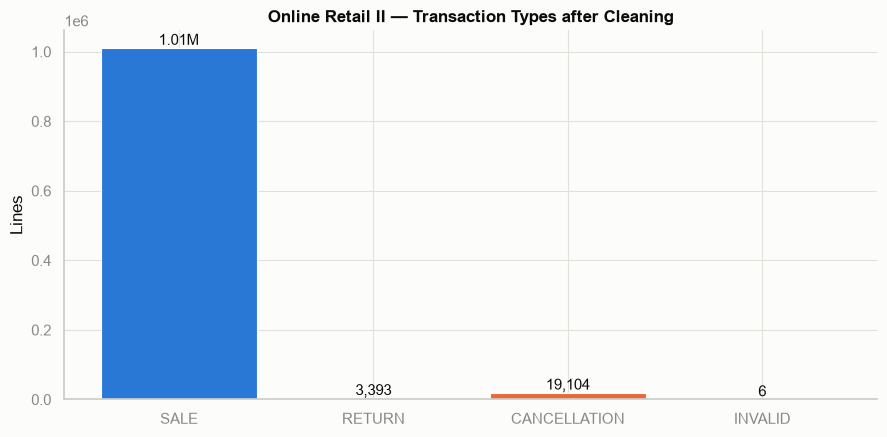

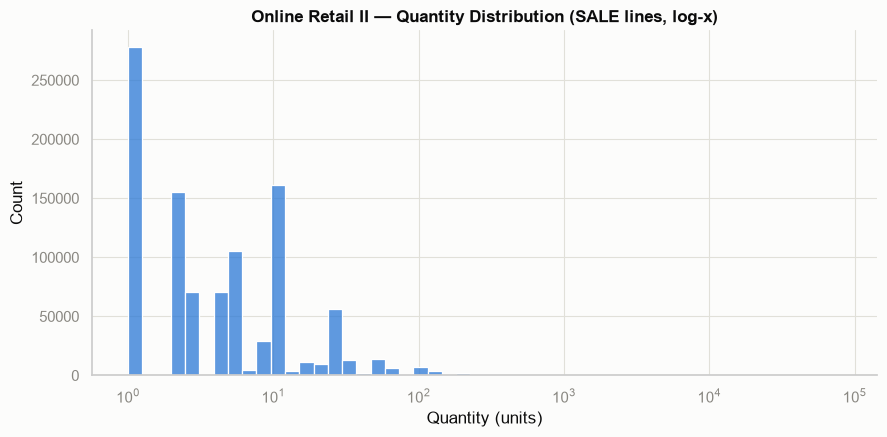

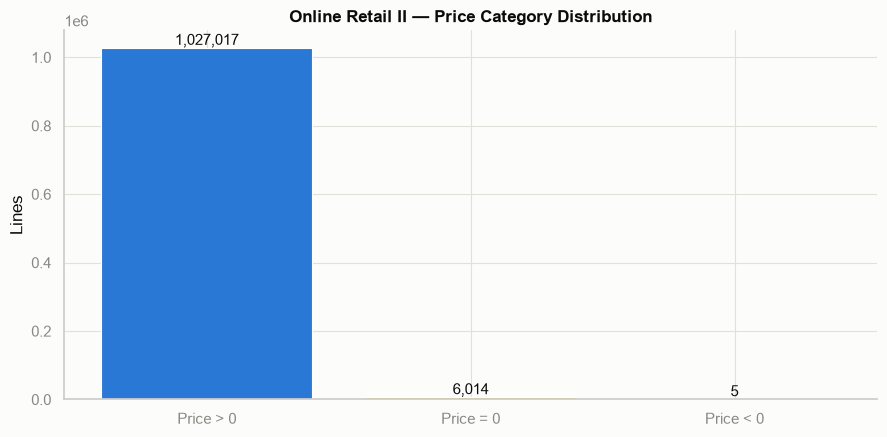

In [33]:
# ---- Outlier / quality visualisations --------------------------------
fig_dir = FIGURES_DIR

# 1. UCI transaction-type split
fig, ax = plt.subplots(figsize=(9, 4.5))
tx_counts = uci_clean['transaction_type'].value_counts().reindex([TX_SALE, TX_RETURN, TX_CANCELLATION, TX_INVALID])
colors = {'SALE': PALETTE[0], 'RETURN': PALETTE[2], 'CANCELLATION': PALETTE[1], 'INVALID': CRITICAL}
bars = ax.bar(tx_counts.index, tx_counts.values, color=[colors[k] for k in tx_counts.index],
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt=lambda v: f'{v/1e6:.2f}M' if v >= 1e6 else f'{v:,.0f}')
ax.set_title('Online Retail II — Transaction Types after Cleaning')
ax.set_ylabel('Lines')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.savefig(os.path.join(fig_dir, 'fig_uci_transaction_types.png')); plt.show()

# 2. UCI Quantity distribution (log scale) — SALE only
fig, ax = plt.subplots(figsize=(9, 4.5))
q = uci_clean.loc[uci_clean['transaction_type']==TX_SALE, 'Quantity']
sns.histplot(q, bins=50, color=PALETTE[0], log_scale=(True, False), ax=ax)
ax.set_title('Online Retail II — Quantity Distribution (SALE lines, log-x)')
ax.set_xlabel('Quantity (units)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.savefig(os.path.join(fig_dir, 'fig_uci_quantity_distribution.png')); plt.show()

# 3. UCI price special transactions
fig, ax = plt.subplots(figsize=(9, 4.5))
pc = uci_clean['price_category'].value_counts().reindex(['PRICE_POSITIVE', 'PRICE_ZERO', 'PRICE_NEGATIVE'])
pc_colors = [PALETTE[0], WARN, CRITICAL]
bars = ax.bar(['Price > 0', 'Price = 0', 'Price < 0'], pc.values, color=pc_colors,
              edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt=lambda v: f'{v:,.0f}')
ax.set_title('Online Retail II — Price Category Distribution')
ax.set_ylabel('Lines')
plt.tight_layout(); plt.savefig(os.path.join(fig_dir, 'fig_uci_price_categories.png')); plt.show()


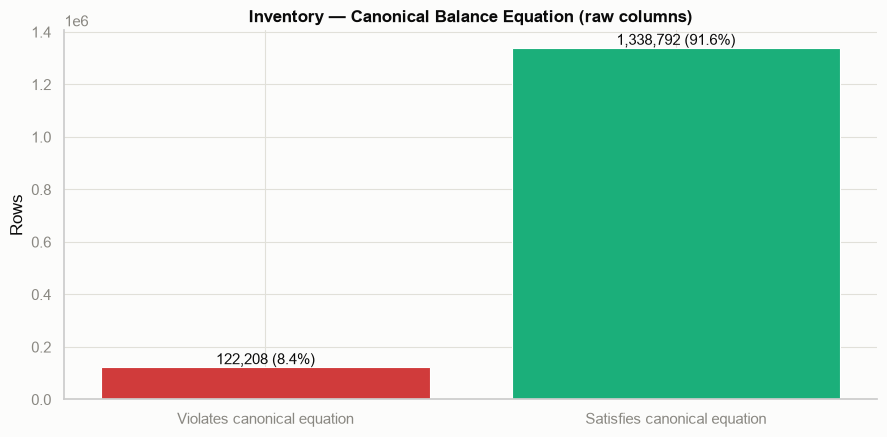

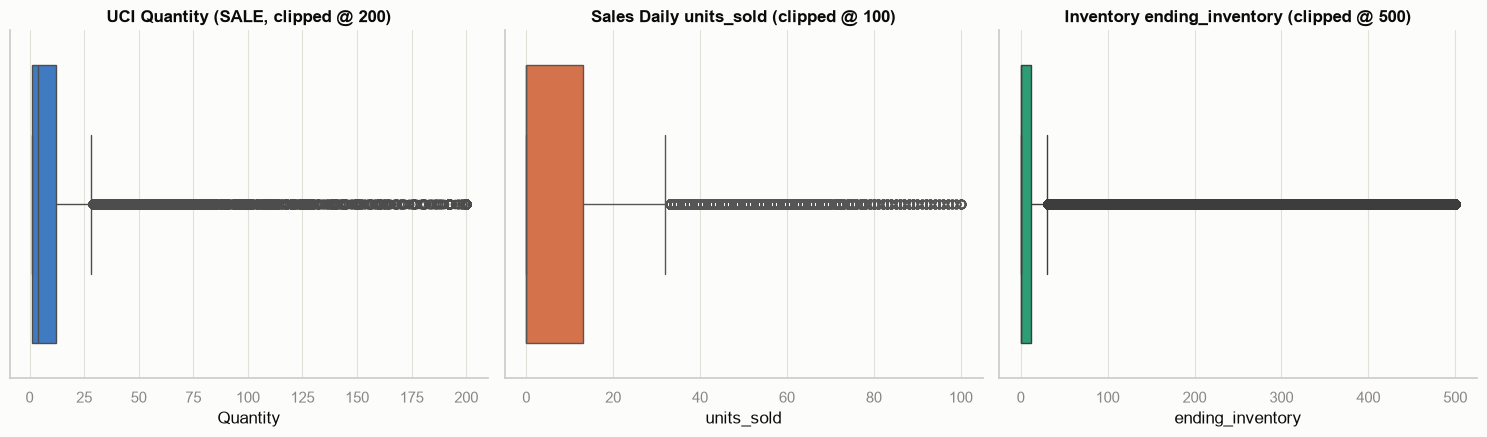

In [34]:
# 4. Inventory balance: before (raw semantics) vs after (derived)
fig, ax = plt.subplots(figsize=(9, 4.5))
vals = [inv_rep['canonical_equation_mismatch_rows'], len(inventory) - inv_rep['canonical_equation_mismatch_rows']]
ax.bar(['Violates canonical equation', 'Satisfies canonical equation'], vals,
       color=[CRITICAL, PALETTE[2]], edgecolor='white', linewidth=0.8)
ax.set_title('Inventory — Canonical Balance Equation (raw columns)')
ax.set_ylabel('Rows')
for i, v in enumerate(vals):
    ax.text(i, v, f'{v:,} ({v/len(inventory)*100:.1f}%)', ha='center', va='bottom')
plt.tight_layout(); plt.savefig(os.path.join(fig_dir, 'fig_inventory_balance.png')); plt.show()

# 5. Outlier boxplots (selected columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
sns.boxplot(x=uci_clean.loc[uci_clean['transaction_type']==TX_SALE, 'Quantity'].clip(upper=200), color=PALETTE[0], ax=axes[0])
axes[0].set_title('UCI Quantity (SALE, clipped @ 200)')
sns.boxplot(x=sales_daily['units_sold'].clip(upper=100), color=PALETTE[1], ax=axes[1])
axes[1].set_title('Sales Daily units_sold (clipped @ 100)')
sns.boxplot(x=inventory['ending_inventory'].clip(upper=500), color=PALETTE[2], ax=axes[2])
axes[2].set_title('Inventory ending_inventory (clipped @ 500)')
plt.tight_layout(); plt.savefig(os.path.join(fig_dir, 'fig_outlier_boxplots.png')); plt.show()


### 14. Final Validation

Automated assertions verify the cleaned datasets satisfy every contract required by later phases: complete schemas, no duplicate keys, valid dates, valid numerics, valid foreign keys, the inventory balance identity, and that the Online Retail components recombine to the full cleaned frame.

In [35]:
# ===== SCHEMA =====
assert set(ONLINE_RETAIL_REQUIRED_COLUMNS).issubset(uci_clean.columns), 'UCI schema incomplete'
for key, req in [('store_master', STORE_MASTER_COLUMNS), ('sku_master', SKU_MASTER_COLUMNS),
                 ('customer_master', CUSTOMER_MASTER_COLUMNS), ('calendar', CALENDAR_COLUMNS),
                 ('sales_daily', SALES_DAILY_COLUMNS), ('inventory_snapshots', INVENTORY_COLUMNS)]:
    assert set(req).issubset(clean[key].columns), f'{key} schema incomplete'
print('PASS: required columns exist in all cleaned datasets')

# ===== DUPLICATES / PRIMARY KEYS =====
assert not uci_clean.duplicated().any(), 'UCI clean still contains duplicates'
assert not store_master['store_id'].duplicated().any(), 'Duplicate store_id'
assert not sku_master['sku_id'].duplicated().any(), 'Duplicate sku_id'
assert not customer_master['customer_id'].duplicated().any(), 'Duplicate customer_id'
assert calendar_clean['date'].duplicated().sum() == 0, 'Duplicate calendar date'
assert not sales_daily.duplicated(['date','store_id','sku_id']).any(), 'Sales grain not unique'
assert not inventory.duplicated(['date','store_id','sku_id']).any(), 'Inventory grain not unique'
print('PASS: no duplicate primary keys / no duplicate fact grain')

# ===== DATES =====
assert int(uci_clean['InvoiceDate'].isna().sum()) == 0, 'UCI InvoiceDate contains invalid/missing dates'
assert uci_clean['InvoiceDate'].between(pd.Timestamp('2009-01-01'), pd.Timestamp('2013-01-01')).all(), \
    'UCI InvoiceDate outside expected 2009-2011 range'
assert int(calendar_clean['parsed_date'].isna().sum()) == 0, 'Calendar contains invalid dates'
print('PASS: dates are valid and in expected ranges')

# ===== NUMERICS =====
assert (sales_daily['units_sold'] >= 0).all(), 'Negative units_sold'
assert (sales_daily['total_revenue'] >= 0).all(), 'Negative total_revenue'
assert (sales_daily['avg_unit_price'] >= 0).all(), 'Negative avg_unit_price'
assert (sales_daily['transaction_count'] >= 0).all(), 'Negative transaction_count'
assert (sales_daily['unique_customers'] >= 0).all(), 'Negative unique_customers'
assert (inventory['beginning_inventory'] >= 0).all(), 'Negative beginning_inventory'
assert (inventory['receipts'] >= 0).all(), 'Negative receipts'
assert (inventory['ending_inventory'] >= 0).all(), 'Negative ending_inventory'
assert (inventory['on_order_qty'] >= 0).all(), 'Negative on_order_qty'
assert (sku_master['cost_price'] > 0).all() and (sku_master['base_price'] > 0).all(), 'Non-positive SKU prices'
assert (store_master['store_size_sqft'] > 0).all(), 'Non-positive store size'
print('PASS: numeric fields are non-negative / positive as required')

# ===== FOREIGN KEYS =====
assert sales_daily['store_id'].isin(store_master['store_id']).all(), 'sales.store_id orphans'
assert sales_daily['sku_id'].isin(sku_master['sku_id']).all(), 'sales.sku_id orphans'
assert sales_daily['date'].isin(calendar_clean['date']).all(), 'sales.date orphans'
assert inventory['store_id'].isin(store_master['store_id']).all(), 'inv.store_id orphans'
assert inventory['sku_id'].isin(sku_master['sku_id']).all(), 'inv.sku_id orphans'
assert inventory['date'].isin(calendar_clean['date']).all(), 'inv.date orphans'
print('PASS: foreign keys are valid (no orphans)')

# ===== INVENTORY BALANCE =====
assert (inventory['beginning_inventory_pre_receipts'] + inventory['receipts']
        - inventory['units_sold'] == inventory['ending_inventory']).all(), 'Inventory balance violated'
print('PASS: canonical inventory balance holds on derived basis')

# ===== UCI COMPONENT RECOMBINATION =====
assert len(uci_sales) + len(uci_returns) + len(uci_cancellations) + len(uci_invalid) == len(uci_clean), \
    'UCI splits do not recombine to the cleaned frame'
print('PASS: Online Retail components recombine exactly to the cleaned frame')

print('\nALL FINAL VALIDATION ASSERTIONS PASSED.')


PASS: required columns exist in all cleaned datasets


PASS: no duplicate primary keys / no duplicate fact grain
PASS: dates are valid and in expected ranges
PASS: numeric fields are non-negative / positive as required


PASS: foreign keys are valid (no orphans)
PASS: canonical inventory balance holds on derived basis
PASS: Online Retail components recombine exactly to the cleaned frame

ALL FINAL VALIDATION ASSERTIONS PASSED.


### 15. Save Processed Data

All cleaned datasets are written to `data/processed/`. The UCI dataset is persisted both as one full cleaned frame and as the analytical components (sales / returns / cancellations / invalid). Large fact tables use Parquet. **`data/raw/` is never modified.**

In [36]:
# ---- Write processed datasets -----------------------------------------
paths = save_processed_data(clean, uci_splits=(uci_sales, uci_returns, uci_cancellations, uci_invalid))


Saved online_retail_clean              -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\online_retail_clean.csv
Saved online_retail_sales              -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\online_retail_sales.csv
Saved online_retail_returns            -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\online_retail_returns.csv
Saved online_retail_cancellations      -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\online_retail_cancellations.csv
Saved online_retail_invalid            -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\online_retail_invalid.csv
Saved store_master_clean               -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\data\processed\store_master_clean.csv
Saved sku_master_clean       

In [37]:
# ---- Verify written outputs are readable and row counts match ----------
expected_rows = {
    'online_retail_clean': len(uci_clean),
    'online_retail_sales': len(uci_sales),
    'online_retail_returns': len(uci_returns),
    'online_retail_cancellations': len(uci_cancellations),
    'online_retail_invalid': len(uci_invalid),
    'store_master_clean': len(store_master),
    'sku_master_clean': len(sku_master),
    'customer_master_clean': len(customer_master),
    'calendar_clean': len(calendar_clean),
    'sales_daily_clean': len(sales_daily),
    'inventory_snapshots_clean': len(inventory),
}
verify = []
for key, p in paths.items():
    n = len(pd.read_parquet(p)) if p.endswith('.parquet') else len(pd.read_csv(p))
    exp = expected_rows.get(key)
    verify.append({'File': os.path.basename(p), 'Rows': n, 'Expected': exp, 'OK': n == exp})
verify_df = pd.DataFrame(verify)
display(verify_df)
assert verify_df['OK'].all(), 'Processed file row-count mismatch'
print('\nAll processed files verified (row counts match in-memory cleaned frames).')


,File,Rows,Expected,OK
0,online_retail_clean.csv,1033036,1033036,True
1,online_retail_sales.csv,1010533,1010533,True
2,online_retail_returns.csv,3393,3393,True
3,online_retail_cancellations.csv,19104,19104,True
4,online_retail_invalid.csv,6,6,True
5,store_master_clean.csv,30,30,True
6,sku_master_clean.csv,5000,5000,True
7,customer_master_clean.csv,10000,10000,True
8,calendar_clean.csv,1461,1461,True
9,sales_daily_clean.parquet,1461000,1461000,True



All processed files verified (row counts match in-memory cleaned frames).


### 16. Data Quality Summary

The data-quality report is persisted to `docs/data_quality_report.json` (full detail) and `docs/data_quality_report.csv` (flat per-dataset summary). The table below summarises the before/after state of every dataset.

In [38]:
# ---- Generate the data-quality report ---------------------------------
summary_df = generate_quality_report(reports)
display(summary_df)


Quality report written -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\docs\data_quality_report.json
Quality report written -> C:\Users\SURAG\Documents\zidio\Project_FORESIGHT\Demand-Inventory-Intelligence\docs\data_quality_report.csv


,Dataset,Dataset Key,Original Rows,Final Rows,Columns,Duplicates Found,Duplicates Removed,Missing Values,Invalid Values,Outliers,Date Range,Quality Status
0,Online Retail II (UCI),online_retail_ii,1067371,1033036,18,34335,34335,243007,6,180630,2009-12-01 07:45:00 to 2011-12-09 12:50:00,REVIEW
1,Store Master,store_master,30,30,8,0,0,0,0,0,2015-08-03 00:00:00 to 2021-12-07 00:00:00,PASS
2,SKU Master,sku_master,5000,5000,12,0,0,0,0,216,N/A,PASS
3,Customer Master,customer_master,10000,10000,5,0,0,0,0,0,2019-01-01 00:00:00 to 2023-12-28 00:00:00,PASS
4,Calendar,calendar,1461,1461,13,0,0,0,0,0,2022-01-01 00:00:00 to 2025-12-31 00:00:00,PASS
5,Sales Daily,sales_daily,1461000,1461000,9,0,0,0,0,308344,N/A,PASS
6,Inventory Snapshots,inventory_snapshots,1461000,1461000,11,0,0,0,122208,416094,N/A,REVIEW


In [39]:
# ---- Before / After summary table -------------------------------------
before_after = pd.DataFrame([
    {'Dataset': 'Online Retail II (UCI)', 'Original': uci_report['original_rows'],
     'Duplicates Found': uci_report['duplicate_rows'], 'Duplicates Removed': uci_report['duplicates_removed'],
     'Missing Values': uci_report['missing_values'], 'Invalid Values': uci_report['invalid_values'],
     'Final': uci_report['final_rows'], 'Status': uci_report['quality_status']},
    {'Dataset': 'Store Master', 'Original': store_rep['original_rows'],
     'Duplicates Found': store_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': store_rep['invalid_values'],
     'Final': store_rep['final_rows'], 'Status': store_rep['quality_status']},
    {'Dataset': 'SKU Master', 'Original': sku_rep['original_rows'],
     'Duplicates Found': sku_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': sku_rep['invalid_values'],
     'Final': sku_rep['final_rows'], 'Status': sku_rep['quality_status']},
    {'Dataset': 'Customer Master', 'Original': cust_rep['original_rows'],
     'Duplicates Found': cust_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': cust_rep['invalid_values'],
     'Final': cust_rep['final_rows'], 'Status': cust_rep['quality_status']},
    {'Dataset': 'Calendar', 'Original': cal_rep['original_rows'],
     'Duplicates Found': cal_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': cal_rep['invalid_values'],
     'Final': cal_rep['final_rows'], 'Status': cal_rep['quality_status']},
    {'Dataset': 'Sales Daily', 'Original': sales_rep['original_rows'],
     'Duplicates Found': sales_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': sales_rep['invalid_values'],
     'Final': sales_rep['final_rows'], 'Status': sales_rep['quality_status']},
    {'Dataset': 'Inventory Snapshots', 'Original': inv_rep['original_rows'],
     'Duplicates Found': inv_rep['duplicate_rows'], 'Duplicates Removed': 0,
     'Missing Values': 0, 'Invalid Values': inv_rep['invalid_values'],
     'Final': inv_rep['final_rows'], 'Status': inv_rep['quality_status']},
])
display(before_after)


,Dataset,Original,Duplicates Found,Duplicates Removed,Missing Values,Invalid Values,Final,Status
0,Online Retail II (UCI),1067371,34335,34335,"{'dataset': 'online_retail_ii', 'missing_by_co...",6,1033036,REVIEW
1,Store Master,30,0,0,0,0,30,PASS
2,SKU Master,5000,0,0,0,0,5000,PASS
3,Customer Master,10000,0,0,0,0,10000,PASS
4,Calendar,1461,0,0,0,0,1461,PASS
5,Sales Daily,1461000,0,0,0,0,1461000,PASS
6,Inventory Snapshots,1461000,0,0,0,122208,1461000,REVIEW


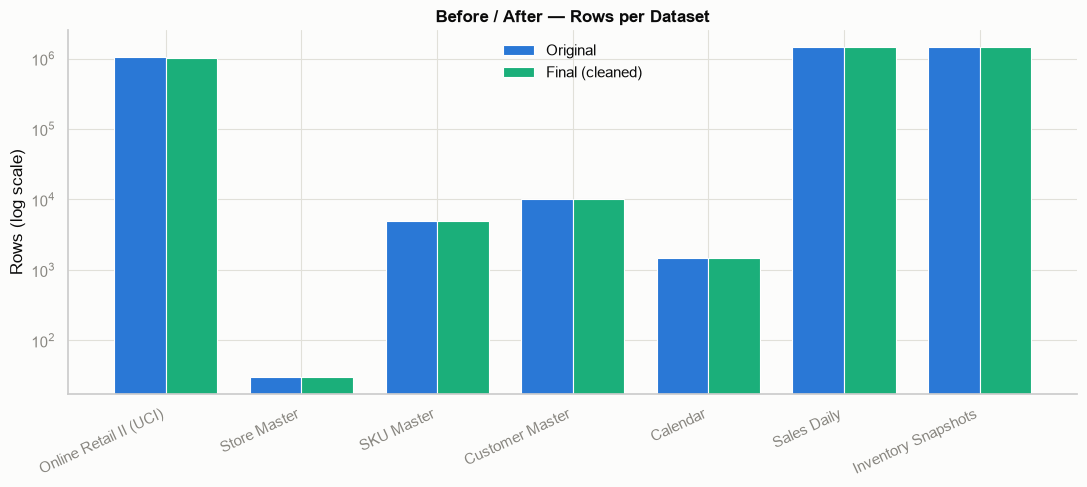

In [40]:
# ---- Before / after visualisation -------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
datasets = before_after['Dataset']
x = np.arange(len(datasets))
w = 0.38
ax.bar(x - w/2, before_after['Original'], w, label='Original', color=PALETTE[0], edgecolor='white', linewidth=0.8)
ax.bar(x + w/2, before_after['Final'], w, label='Final (cleaned)', color=PALETTE[2], edgecolor='white', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(datasets, rotation=25, ha='right')
ax.set_yscale('log')
ax.set_ylabel('Rows (log scale)')
ax.set_title('Before / After — Rows per Dataset')
ax.legend(frameon=False)
plt.tight_layout(); plt.savefig(os.path.join(FIGURES_DIR, 'fig_before_after_rows.png')); plt.show()


### 16.1 Cleaning Decisions — Summary

**Online Retail II (UCI)**

- **Exact duplicates (34,335 rows, 3.22%)** were confirmed as exact full-row repeats and removed; the raw file was not touched.
- **Cancellations (19,104 lines, 1.79% of raw)** were identified by the `C` invoice prefix and kept in `online_retail_cancellations.csv` — not deleted.
- **Returns (3,393 non-C negative-quantity lines)** were kept in `online_retail_returns.csv`. Many carry zero price and act as inventory adjustment lines; they remain available for return analytics.
- **Invalid / accounting lines (6)** — the `A`-prefixed `Adjust bad debt` journal lines — were separated and excluded from sales.
- **Zero-price special lines (6,014)** (postage, samples, manual adjustments) were kept in the SALE stream and flagged with `is_special_transaction` for downstream filtering.
- **Missing Descriptions (4,382)** were recovered from the same StockCode wherever possible (4,275 after dedup; 3,912 recovered, 363 unrecoverable labelled `Unknown Product`).
- **Missing Customer ID (22.76% after dedup)** was treated as guest checkout, kept for demand analysis and flagged with `is_guest_transaction`.

**Synthetic multi-store dataset**

- All master tables passed: unique IDs, valid prices/lead-times/sizes, valid segments and loyalty flags, internally consistent calendar.
- `sales_daily` passed: unique `(date, store, sku)` grain, non-negative numbers, `revenue == units * price`, promotion flags `{0,1}`, and zero orphan references.
- `inventory_snapshots`: the canonical balance equation fails on 8.36% of rows because `beginning_inventory` **already includes** the day's receipts. We documented this semantic, added the derived column `beginning_inventory_pre_receipts`, and verified the canonical equation holds on 100% of rows on that basis.

**Outliers** were investigated (IQR + Z-score) but **not removed** — they represent legitimate extreme retail transactions.

**Phase 3 is complete.** No EDA, feature engineering, forecasting or visualisation app has been started, per the phase boundary.

---
**End of Phase 3.** Next step (after approval): **Phase 4 — Data Integration & Common Analytical Model**.